# Predicting density change in Lima, Peru

## Preparation

- [Github link](https://github.com/Tbtaaa/DSSS_Assessment_TP) 

- Number of words: ***

- Runtime: ~10 minutes (Memory 10 GB, CPU Intel i7-10700 @2.90GHz)

- Coding environment: Jupyter Notebook (Python 3.12, Conda environment)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library
    - **shap** (model interpretation)
    - **scikit-learn** (machine learning)

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

Urban population growth in Latin American cities is shaped by a complex interaction of physical, socio-economic, and infrastructural factors. While transport systems are often assumed to influence urban development through improved accessibility, their role should be understood as part of a broader set of conditions that structure how cities evolve over time.

Lima, Peru, offers a particularly relevant context to examine these dynamics. As a large metropolitan area characterised by socio-spatial fragmentation, Lima has experienced significant changes in both population distribution and urban form. Between 2007 and 2017, the city underwent a period of moderate but spatially uneven density change, alongside the introduction of major transport infrastructure such as the Metropolitano Bus Rapid Transit system and Line 1 of the Lima Metro. However, it remains unclear to what extent these changes can be explained by accessibility improvements alone, or whether other constraints—such as topography and socio-economic conditions—play a more significant role.

This study investigates whether urban and accessibility-related features can predict changes in population density in Lima between 2007 and 2017. Using a supervised machine learning approach, the analysis considers multiple explanatory variables, including accessibility to transport systems, terrain conditions, and socio-economic characteristics, at the hexagon level. Rather than assuming a dominant role for any single factor, this approach evaluates the relative contribution of different variables to density change.

## Research questions

[[ go back to the top ]](#Table-of-contents)

This study addresses the following research questions:

**Can urban and accessibility features predict density change in Lima between 2007 and 2017?** Specifically, which variables contribute most to explaining density change, and to what extent does model performance suggest that important drivers may be missing from the dataset?

## Data

[[ go back to the top ]](#Table-of-contents)

*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

Population density change was measured using the logarithmic transformation of the ratio between 2017 and 2007 densities (log(dn_2017 / dn_2007)). This approach captures proportional rather than absolute change, making it more suitable for comparing areas with different initial density levels. In addition, the transformation reduces skewness and limits the influence of extreme values, resulting in a more stable and interpretable dependent variable.

| Variable   | Type        | Role      | Description                                                            |
| ---------- | ----------- | --------- | ---------------------------------------------------------------------- |
| MT_prox    | Binary      | Predictor | Indicator for proximity to metropolitan transport infrastructure       |
| CPT_rt     | Numeric     | Predictor | Number of conventional public transport routes                         |
| dns_dfflog | Numeric     | Target    | Logarithmic change in population density between 2007 and 2017         |
| attrac     | Binary      | Predictor | Indicator: 1 if the hexagon intersects an area previously identified as a metropolitan attractor    |
| slop_md    | Numeric     | Predictor | Median slope value                                                     |
| SES        | Numeric     | Predictor | Mean socio-economic status                                             |

## Methodology

[[ go back to the top ]](#Table-of-contents)

![Flowchart](graph_01.jpg)

#### Data preparation and check

- importa dataset: explain how it was built
- create log density change 
- analyze binary variables: The attraction variable is highly imbalanced, with only a small proportion of hexagons classified as attractors.

DEPENDENT VARIABLES 
- Check the distribution of the dependent variables: The dependent variable shows a relatively symmetric distribution centred around zero, indicating balanced patterns of density increase and decline.
- check null values for dependent variables: drop few values

INDEPENDENT VARIABLES
- Check distributions of all the variables: CPT_rt shows a highly skewed distribution, with most areas having low values. This reflects uneven distribution of conventional public transport across the city.
- Check for correlation: No strong multicollinearity is observed among predictors. The weak correlation between predictors and the dependent variable suggests that density change is not strongly explained by the selected variables alone. Low explanatory power, density change appears to be driven by more complex or unobserved factors beyond accessibility and physical conditions.

In [1]:
#!pip install shap

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import dataset
hex = gpd.read_file("data/hexagon_grid/hex_clean_.shp")
hex.columns

Index(['hex_id', 'dn_2007', 'dn_2017', 'dns_dff', 'SES', 'slop_md', 'CPT_rt',
       'MT_prox', 'MT_group', 'attrac', 'geometry'],
      dtype='object')

In [4]:
# Create log density change  
hex["dns_dfflog"] = np.where(
    (hex["dn_2007"] > 0) & (hex["dn_2017"] > 0),
    np.log(hex["dn_2017"] / hex["dn_2007"]),
    np.nan)

# Clean dataset with columns to use and examinate
vars_keep = ["SES", "slop_md", "CPT_rt", "MT_prox", "attrac","dns_dfflog"]
hex_df = hex[vars_keep].copy()
hex_df.describe

<bound method NDFrame.describe of        SES  slop_md  CPT_rt  MT_prox  attrac  dns_dfflog
0      4.0     5.71     0.0      0.0       0   -0.298431
1      4.0     5.11     0.0      0.0       0   -1.058161
2      2.0    11.31     0.0      0.0       0   -0.611660
3      3.0     6.89     0.0      0.0       0   -1.247110
4      3.0    11.64     0.0      0.0       0   -1.595559
...    ...      ...     ...      ...     ...         ...
15323  3.0     5.42     6.0      0.0       0   -0.258784
15324  2.0    37.09     0.0      0.0       0   -0.247677
15325  3.0     6.45     5.0      0.0       0   -2.964682
15326  3.0     6.89     0.0      0.0       0    0.056873
15327  2.0    40.00     0.0      0.0       0    0.920860

[15328 rows x 6 columns]>

In [5]:
# Examinate binary variables
print(hex_df["MT_prox"].value_counts(dropna=False))
print(hex_df["attrac"].value_counts(dropna=False))

MT_prox
0.0    14001
1.0     1327
Name: count, dtype: int64
attrac
0    15123
1      205
Name: count, dtype: int64


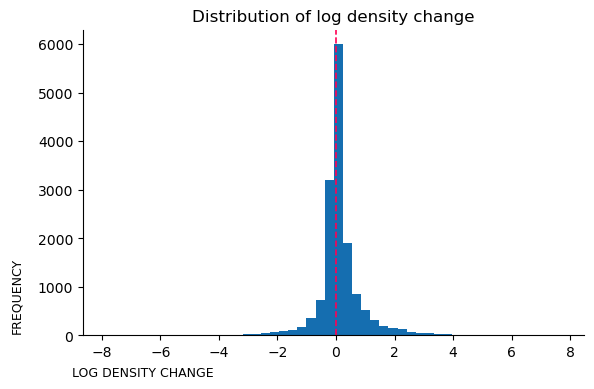

In [6]:
# Check the distribution of the dependent variable
fig, ax = plt.subplots(figsize=(6, 4))

hex_df["dns_dfflog"].hist(bins=50,ax=ax,color="#156eb0",)

ax.set_title("Distribution of log density change", fontsize=12)
ax.set_xlabel("LOG DENSITY CHANGE", fontsize=9)
ax.set_ylabel("FREQUENCY", fontsize=9)

ax.xaxis.set_label_coords(0.12, -0.1)
ax.yaxis.set_label_coords(-0.12, 0.13)

# remove right and top lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# left and bottom lines
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.grid(False)
ax.axvline(x=0, color='#ff0054', linewidth=1.2, linestyle='--')

plt.tight_layout()
plt.show()

In [7]:
# Check for missing values
hex_df.isna().sum()

SES            0
slop_md        0
CPT_rt         0
MT_prox        0
attrac         0
dns_dfflog    44
dtype: int64

In [8]:
# Just 44 with missing values, drop them
hex_df = hex_df.dropna()

In [9]:
# Check final version of dependent variable
hex_df["dns_dfflog"].describe()

count    15284.000000
mean         0.124894
std          0.881460
min         -7.861342
25%         -0.135974
50%          0.033618
75%          0.298480
max          7.705938
Name: dns_dfflog, dtype: float64

In [10]:
# Check all independent variables
for col in hex_df.columns:
    print(col, hex_df[col].nunique())

SES 5
slop_md 1081
CPT_rt 86
MT_prox 2
attrac 2
dns_dfflog 15086


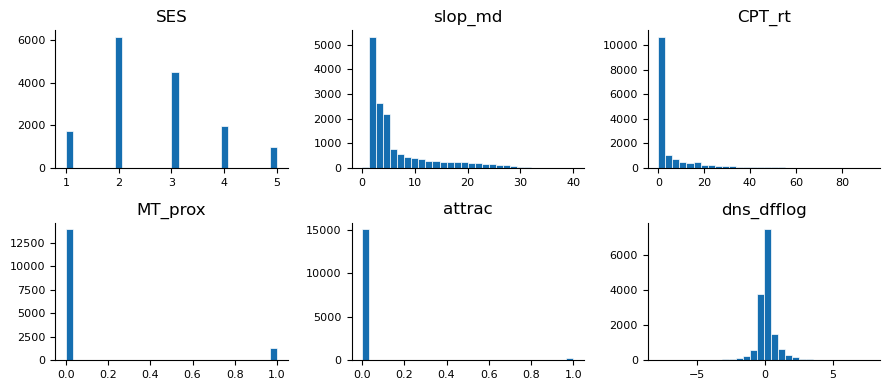

In [11]:
# Check distributions of all the variables
fig, axes = plt.subplots(2, 3, figsize=(9, 4))

# create histograms
hex_df.hist(ax=axes.flatten(), bins=30, color="#156eb0", edgecolor="white", linewidth=0.5)

# apply style to all plots
for ax in axes.flatten():
    
    # delete grid
    ax.grid(False)
    
    # remove right and top lines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # left and bottom lines
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(labelsize=8)

# ajustar layout
plt.tight_layout()
plt.show()

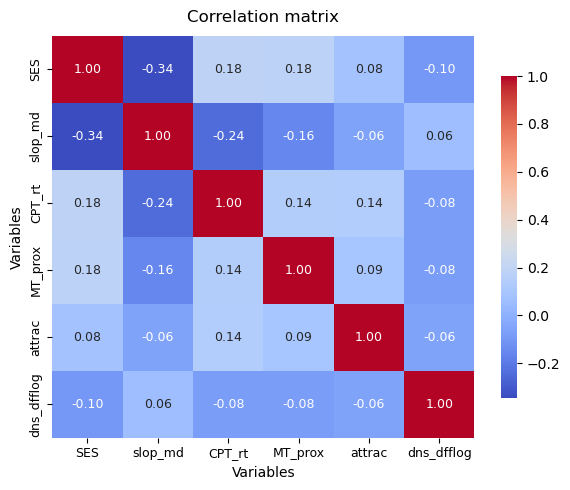

In [16]:
# Check correlation of independent variables 
corr = hex_df.corr(numeric_only=True)
plt.figure(figsize=(6, 5))

ax = sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",               
    annot_kws={"size": 9},    
    cbar_kws={"shrink": 0.8}   
)

# title
ax.set_title("Correlation matrix", fontsize=12, pad=10)

# labels
ax.set_xlabel("Variables", fontsize=10)
ax.set_ylabel("Variables", fontsize=10)

# ticks size
ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()

In [17]:
# Check final dataset
hex_df.shape

(15284, 6)

#### Analysis

- split train test
- random forest
- evaluate predictions
- Feature importance
- Permutation importance
- SHAP global

The negative R² suggests that the model performs worse than a naive mean-based prediction, indicating that density change is not strongly explained by the selected accessibility, physical, and socio-economic variables.
These results suggest that population density change is driven by more complex and potentially unobserved processes beyond accessibility and basic urban characteristics.
Contrary to expectations from TOD theory, accessibility alone does not appear to be a strong predictor of density change in this context.

In [18]:
# split train/test
X = hex_df.drop(columns=["dns_dfflog"])
y = hex_df["dns_dfflog"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
# Random forest regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
# Evaluation
y_pred = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2: -0.18985420540937614
RMSE: 0.9561004788023221


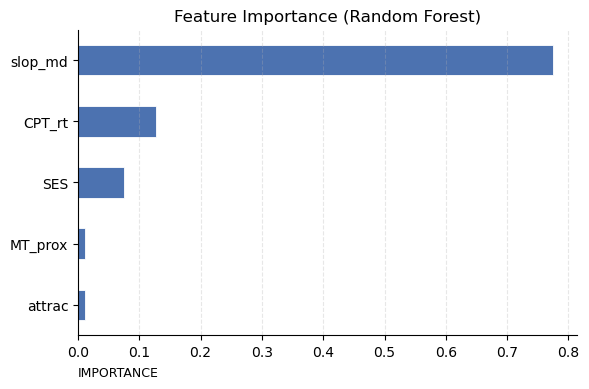

slop_md    0.774600
CPT_rt     0.127309
SES        0.075230
MT_prox    0.011901
attrac     0.010960
dtype: float64


In [21]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)  # horizontal

fig, ax = plt.subplots(figsize=(6, 4))

feat_imp.plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.6)

# title
ax.set_title("Feature Importance (Random Forest)", fontsize=12)
ax.set_xlabel("IMPORTANCE", fontsize=9)
ax.set_ylabel("")

ax.xaxis.set_label_coords(0.08, -0.1)

# # remove right and top lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# smooth grid
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(feat_imp.sort_values(ascending=False))

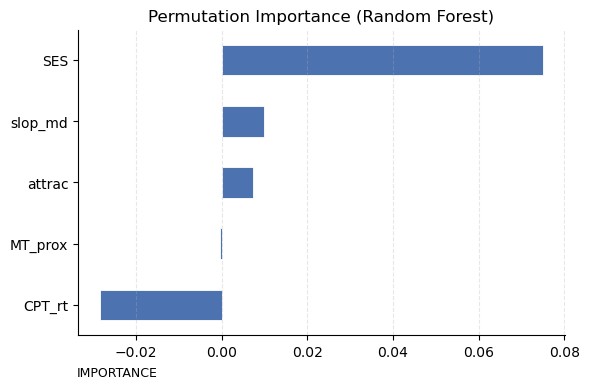

SES        0.074908
slop_md    0.009970
attrac     0.007222
MT_prox   -0.000301
CPT_rt    -0.028338
dtype: float64


In [22]:
# Permutation importance
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10,
    random_state=42)

perm_imp = pd.Series(perm.importances_mean, index=X.columns)
perm_imp = perm_imp.sort_values(ascending=True)  # horizontal

fig, ax = plt.subplots(figsize=(6, 4))

perm_imp.plot(
    kind="barh",
    ax=ax,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.6)

# titles
ax.set_title("Permutation Importance (Random Forest)", fontsize=12)
ax.set_xlabel("IMPORTANCE", fontsize=9)
ax.set_ylabel("")

ax.xaxis.set_label_coords(0.08, -0.1)

# clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# grid
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(perm_imp.sort_values(ascending=False))

 99%|===================| 3040/3057 [01:36<00:00]        

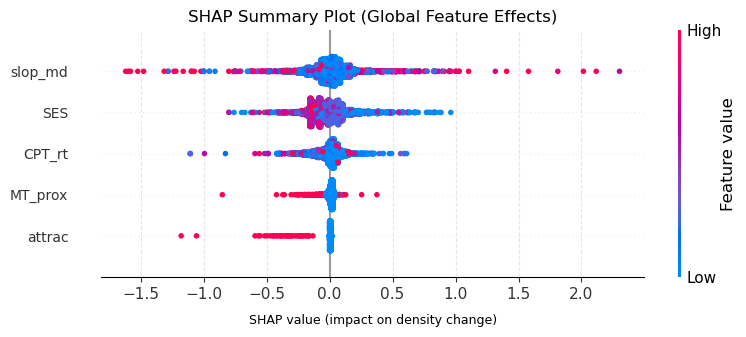

In [24]:
# SHAP GLOBAL 
plt.figure(figsize=(6, 5))

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test, check_additivity=False)
shap.summary_plot(
    shap_values,
    X_test,
    show=False)

plt.title("SHAP Summary Plot (Global Feature Effects)", fontsize=12)
plt.xlabel("SHAP value (impact on density change)", fontsize=9)
plt.ylabel("")

# clean style
ax = plt.gca()
ax.tick_params(axis='y', labelsize=10)
ax.xaxis.set_label_coords(0.5, -0.15)

# grid
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
high = y_test.sort_values(ascending=False).index[0]
low = y_test.sort_values(ascending=True).index[0]

print(high, low)

In [ ]:
i = 10  # cambia el índice

plt.figure(figsize=(5, 4))
shap.plots.waterfall(shap_values[i], show=False)

ax = plt.gca()

# titles
ax.set_title("Local SHAP Explanation (Hexagon)", fontsize=12)

# labels
ax.tick_params(axis='both', labelsize=10)

# clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
i = 1335  # cambia el índice

plt.figure(figsize=(5, 4))
shap.plots.waterfall(shap_values[i], show=False)

ax = plt.gca()

# titles
ax.set_title("Local SHAP Explanation (Hexagon)", fontsize=12)

# labels
ax.tick_params(axis='both', labelsize=10)

# clean
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
i = 1359  # cambia el índice

shap.plots.waterfall(shap_values[i])

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

#AI

The limited predictive performance of the model suggests that the selected variables do not adequately capture the key processes driving density change in Lima. A substantial body of literature highlights the importance of informal urbanisation (De Soto, 1989; Roy, 2005), land market dynamics (Harvey, 1985; Smith, 1979), and regulatory frameworks (Vega Centeno, 2017) in shaping urban growth in Latin American cities. In addition, the role of urban form and path dependency (Jacobs, 1961) further suggests that density change is influenced by pre-existing spatial structures. These processes are often not systematically captured in available datasets, particularly in contexts such as Lima where informal development plays a dominant role (Calderón, 2015).

## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)


By combining regression and tree-based models with model interpretation techniques, this research aims to better understand the drivers of urban growth in Lima, highlighting the extent to which density change can be explained by observable spatial variables, and where important dynamics may remain unobserved.